# DS09 · Standardization, percent signal change, and reference choices

<!-- paper-first -->
### Research question

**Reading:** [PB01](../../curriculum/papers/measurement.md#pb01). Review the assigned figure or result before starting the lesson.

**Question:** Does converting a signal into z scores change what biological process the signal measures?

Record a prediction, a source location, and one point you want this lesson to clarify. Ask your AI tutor to distinguish the paper’s evidence from its interpretation.
<!-- /paper-first -->

<!-- key-references -->
### Why this technique matters

Every fMRI pipeline (AFNI afni_proc.py, FSL FEAT, SPM, nilearn) requires choosing how raw scanner intensities are scaled before regression or multivariate decoding. Dividing by baseline equilibrium magnetization converts arbitrary scanner units into physical percent signal change (PSC) that cancels multiplicative coil gain, whereas temporal z-scoring divides by the total time-series standard deviation and confounds true neural response amplitude with thermal and physiological noise (Chen et al., 2017; Welvaert & Rosseel, 2013). Standardization choices also determine the reference axis (temporal axis=0 vs. spatial axis=1) and baseline definition (rest-period vs. whole-run mean), which directly alter effect-size magnitudes across regions and cohorts.

**Key references** · *Feature scaling, baseline normalization (percent signal change), and temporal vs. spatial standardization*

- *Foundational* — Chen et al. (2017), [Is the statistic value all we should care about in neuroimaging?](https://doi.org/10.1016/j.neuroimage.2016.09.066), *NeuroImage*. Demonstrates why fMRI effect estimates should be reported in physical units (percent signal change) alongside dimensionless test statistics so response amplitude is not confounded with noise.
- *Standard tool* — Reynolds et al. (2024), [Processing, evaluating, and understanding FMRI data with afni\_proc.py](https://doi.org/10.1162/imag_a_00347), *Imaging Neuroscience*. Details modern fMRI preprocessing and scaling conventions in afni_proc.py, including voxelwise mean normalization to percent signal change and quality-control diagnostics.
- *Critical evaluation* — Welvaert and Rosseel (2013), [On the Definition of Signal-To-Noise Ratio and Contrast-To-Noise Ratio for fMRI Data](https://doi.org/10.1371/journal.pone.0077089), *PLoS ONE*. Formalizes the definitions of fMRI signal-to-noise ratio (tSNR) and contrast-to-noise ratio (CNR), clarifying how temporal z-scoring converts effect amplitudes into CNR-weighted quantities.
- *Review* — Pernet (2014), [Misconceptions in the use of the General Linear Model applied to functional MRI: a tutorial for junior neuro-imagers](https://doi.org/10.3389/fnins.2014.00001), *Frontiers in Neuroscience*. Reviews common misconceptions in applying the GLM to fMRI, including grand-mean vs. voxelwise baseline scaling and percent signal change interpretation.

Full entries, verification status and citation counts: [course bibliography](../../curriculum/papers/REFERENCES.md#ds09).
<!-- /key-references -->

**Format:** 75–100 minutes of guided work, plus 30–60 minutes in the assigned existing course material. **Prerequisite:** the foundations notebooks; follow this strand in order. The core exercise is synthetic, offline, and independently runnable. It demonstrates mechanics, not a validated participant-data analysis.

## Existing course material

Read [Data 8: SD and the normal curve](https://github.com/data-8/textbook/blob/5235b7653f8dfaeb90e43419b9aa069322f2d60b/chapters/14/3/SD_and_the_Normal_Curve.ipynb). Use the indicated topic, then return here to apply it to a neuroimaging question. Berkeley material is linked in its original form, not adapted or redistributed; its CC BY-NC-ND terms remain upstream. Neuromatch material is CC BY 4.0 with separately licensed software; selected unmodified copies live in `third_party/data_science`. The explanation and dataset below are original.

## Understand the transformation

### 1. Motivation from the Assigned Papers: What Biological Quantity Does a Standardized BOLD Signal Measure?

Raw functional MRI intensities coming off a 3T or 7T scanner have arbitrary digital scaling (`a.u.`) that depends on receiver coil gain, transmitter calibration, $T_2^*$ weighting, and distance from the surface array elements. Before comparing task-evoked responses across cortical regions, sessions, or participants, every pipeline applies a **signal standardization** transformation. Yet two popular choices—**Percent Signal Change ($\text{PSC}$)** and **Temporal $z$-Scoring**—answer fundamentally different biophysical questions:

- **Logothetis et al. (2001), *Neurophysiological investigation of the basis of the fMRI signal* (`PB01`, Abstract, Figures 3–4, and Discussion):** Simultaneous intracortical microelectrode recordings (local field potentials $\text{LFP}$ and multi-unit spiking activity $\text{MUA}$) and BOLD fMRI in primate visual cortex established that the fractional change in deoxyhemoglobin-sensitive $T_2^*$ signal ($\Delta S / S_0$, expressed in percent signal change $\text{PSC}$) is approximately linear with respect to local synaptic input ($\text{LFP}$) over moderate contrast ranges. Crucially, the biophysical coupling connects neural activity to the **fractional modulation relative to local baseline equilibrium magnetization $S_0$** ($\Delta S / S_0$), **not** to the ratio of signal modulation to thermal receiver noise ($\Delta S / \sigma_{\text{noise}}$). If a voxel near a large pial vein or a noisy surface coil has $3\times$ higher thermal/physiological noise $\sigma$, temporal $z$-scoring divides its task-evoked BOLD response by $3\times$, making an identical neural response look $3\times$ smaller.

### 2. Relation to Graduate Courses and Upstream Modules

This lesson bridges **UC Berkeley Data 8 (Chapter 14.3: Standard Deviation and the Normal Curve / Standard Units)** and **Data 100 (Feature Scaling & Affine Transformations)** with **USC NIIN 540/580 (BOLD Physics, Temporal SNR, and Percent Signal Change Calibration)** and **Stanford Psych 204B**. Students learn to distinguish affine rescalings that preserve relative effect magnitudes from variance-normalizing transforms that convert effect sizes into signal-to-noise ratios ($t$-like units).

### 3. Mathematical Formulation: Raw Units, Percent Signal Change ($\text{PSC}$), and Temporal $z$-Scores

Consider a single voxel's time series $y_t$ ($t = 1, \dots, T$) generated by a baseline equilibrium signal $B_0 > 0$, a zero-mean unit-amplitude hemodynamic task regressor $x_t$ ($\frac{1}{T}\sum_t x_t = 0, \frac{1}{T}\sum_t x_t^2 = 1$), a true fractional neural-hemodynamic coupling $\beta_{\text{frac}}$ (so the physical BOLD amplitude is $\Delta S = B_0 \beta_{\text{frac}}$), and additive noise $\epsilon_t \sim (0, \sigma_\epsilon^2)$:
$$y_t = B_0 \left(1 + \beta_{\text{frac}}\, x_t\right) + \epsilon_t = B_0 + \Delta S \, x_t + \epsilon_t$$
Assume the scanner applies an arbitrary unknown multiplicative receiver gain $g > 0$ at that voxel location, so the recorded digital intensity is $\tilde{y}_t = g \, y_t$.

#### A. Raw Scanner Units (Gain-Confounded)
Fitting ordinary least squares of $\tilde{y}_t$ on $x_t$ yields the raw regression slope:
$$\hat{\beta}_{\text{raw}} = g \, B_0 \, \beta_{\text{frac}} + \eta, \qquad \mathbb{E}[\hat{\beta}_{\text{raw}}] = g \, B_0 \, \beta_{\text{frac}}$$
Because $\hat{\beta}_{\text{raw}}$ is proportional to the arbitrary coil gain $g$, a cortical parcel closer to the head coil ($g = 2.5$) appears to have $2.5\times$ stronger neural activation than a deeper parcel ($g = 1.0$) with the exact same $\beta_{\text{frac}}$.

#### B. Percent Signal Change ($\text{PSC}$: Gain-Invariant, Noise-Decoupled)
Dividing centered fluctuations by the baseline reference $\bar{\tilde{y}} \approx g B_0$ and multiplying by $100$ cancels the arbitrary coil gain $g$ exactly:
$$\text{PSC}_t = 100 \cdot \frac{\tilde{y}_t - \bar{\tilde{y}}}{\bar{\tilde{y}}} \approx 100 \cdot \beta_{\text{frac}}\, x_t + 100 \cdot \frac{\epsilon_t}{B_0}$$
The expected task regression slope on $\text{PSC}_t$ is:
$$\mathbb{E}\!\left[\hat{\beta}_{\text{PSC}}\right] = 100 \cdot \beta_{\text{frac}} \quad (\text{in } \% \text{ BOLD change})$$
Notice three key properties:
1. **Gain invariance:** $g$ cancels in numerator and denominator.
2. **Noise-level invariance of expected amplitude:** Changing thermal noise $\sigma_\epsilon$ changes the *precision* (standard error) of $\hat{\beta}_{\text{PSC}}$, but does **not** bias its expected value $\mathbb{E}[\hat{\beta}_{\text{PSC}}]$.
3. **Reference choice (`Baseline` vs `Whole-Run Mean`):** In block designs with high duty cycle $d \in (0, 1)$ (where task is ON for fraction $d$ of the scan with positive response $\Delta S > 0$), the whole-run mean is $\bar{y}_{\text{run}} = B_0 + d\,\Delta S > B_0$. Dividing by $\bar{y}_{\text{run}}$ instead of the pre-stimulus rest baseline $\bar{y}_{\text{rest}} = B_0$ underestimates $\text{PSC}$ by a factor of $\frac{1}{1 + d\,\beta_{\text{frac}}}$.

#### C. Temporal $z$-Scoring (Conflates Effect Amplitude $\Delta S$ with Noise $\sigma_\epsilon$)
Standardizing a voxel across time to zero mean and unit variance defines:
$$z_t = \frac{\tilde{y}_t - \bar{\tilde{y}}}{s_{\tilde{y}}}, \qquad \text{where } s_{\tilde{y}}^2 = (g B_0 \beta_{\text{frac}})^2 + g^2 \sigma_\epsilon^2$$
Regressing $z_t$ on unit-variance $x_t$ yields an expected slope equal to the Pearson correlation $r(x, y)$:
$$\mathbb{E}\!\left[\hat{\beta}_{z}\right] \approx \frac{\Delta S}{\sqrt{\Delta S^2 + \sigma_\epsilon^2}} = \frac{\text{CNR}}{\sqrt{\text{CNR}^2 + 1}}, \qquad \text{where } \text{CNR} = \frac{\Delta S}{\sigma_\epsilon} = \beta_{\text{frac}} \cdot \text{tSNR}$$
Therefore, temporal $z$-scoring **destroys pure amplitude information**: two subjects or brain regions with identical neural response $\beta_{\text{frac}} = 2.0\%$ but different thermal/motion noise ($\sigma_\epsilon = 0.5\%$ vs $\sigma_\epsilon = 2.0\%$) will have wildly different $z$-scored slopes ($\hat{\beta}_z = 0.97$ vs $\hat{\beta}_z = 0.71$).

### 4. Transformation & Bookkeeping Contract

| Standardization Transform | Formula | Cancels Coil Gain $g$? | Invariant to Noise $\sigma_\epsilon$? | Physical / Statistical Units |
| :--- | :--- | :--- | :--- | :--- |
| **Raw Centered** ($\tilde{y}_t - \bar{\tilde{y}}$) | $\tilde{y}_t - \frac{1}{T}\sum \tilde{y}_\tau$ | **No** ($\propto g B_0$) | **Yes** (in expectation) | Arbitrary scanner digital units (a.u.) |
| **Rest-Baseline PSC** ($\text{PSC}^{\text{rest}}_t$) | $100(\tilde{y}_t - \bar{\tilde{y}}_{\text{rest}}) / \bar{\tilde{y}}_{\text{rest}}$ | **Yes** | **Yes** (in expectation) | $\%$ of resting equilibrium $S_0$ (`PB01`) |
| **Whole-Run Mean PSC** ($\text{PSC}^{\text{run}}_t$) | $100(\tilde{y}_t - \bar{\tilde{y}}_{\text{run}}) / \bar{\tilde{y}}_{\text{run}}$ | **Yes** | **Yes** (attenuated by $1 + d\beta_{\text{frac}}$) | $\%$ of temporal mean $\bar{y}$ |
| **Temporal $z$-Score** ($z_t$) | $(\tilde{y}_t - \bar{\tilde{y}}) / s_{\tilde{y}}$ | **Yes** | **NO ($\propto \text{CNR} / \sqrt{\text{CNR}^2+1}$)** | Standard deviations ($s_y$ units; correlation-like) |
| **Spatial $z$-Score (Wrong Axis)** | $(\tilde{y}_{v,t} - \bar{\tilde{y}}_{\cdot,t}) / s_{\cdot,t}$ | **No** (mixes tissues) | **No** | Standard deviations across voxels at time $t$ |

## AI-guided prediction (Suggestive prompt for macOS Goose + Ollama: Qwen & Gemma)

Before running the code cells, predict the behavior of each standardization and test an AI tutor with this prompt:

> Consider three cortical ROIs with the **exact same true neural-hemodynamic fractional response** ($\text{PSC} = +2.00\%$ during task blocks relative to rest baseline):
> - **ROI 1 (Deep Cortical):** Coil gain $g = 1.0$, baseline $B_0 = 800$, low thermal noise ($\sigma = 0.4\%$ of baseline).
> - **ROI 2 (Surface Coil Proximity):** Coil gain $g = 2.5$ ($g B_0 = 2000$), low thermal noise ($\sigma = 0.4\%$ of baseline).
> - **ROI 3 (Noisy Physiological / High-Field Voxel):** Coil gain $g = 1.0$ ($B_0 = 800$), high noise ($\sigma = 2.5\%$ of baseline).
> 1. Which ROI appears to have the largest effect under raw centered units, under Percent Signal Change ($\text{PSC}$), and under temporal $z$-scoring?
> 2. What happens to $\text{PSC}$ if you divide by the whole-run mean instead of the pre-task rest baseline when the task block is active for $70\%$ of the scan?


### Part 1 · Core Mathematical Implementation: Comparing Raw Units, Percent Signal Change ($\text{PSC}$), and Temporal $z$-Scoring Across Biophysical Regimes

We simulate $T = 200$ TRs for the three cortical ROIs described above—all sharing the **exact same true fractional BOLD response $\beta_{\text{PSC}} = +2.00\%$** (`PB01`), but differing in receiver coil gain ($g = 1.0$ vs $2.5$) and noise level ($\sigma_{\text{noise}} = 0.4\%$ vs $2.5\%$). We verify mathematically and empirically that:
- Raw OLS slopes are confounded by coil gain $g$ ($2.5\times$ inflation in ROI 2),
- Temporal $z$-scored OLS slopes are confounded by noise $\sigma_{\text{noise}}$ ($2.8\times$ attenuation in ROI 3), and
- Rest-baseline Percent Signal Change ($\text{PSC}$) recovers $+2.00\%$ across all three ROIs.


In [1]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(909)
T_tr = 200
# Block design: 25% duty cycle (50 TRs task ON = 1.0, 150 TRs rest OFF = 0.0)
task_indicator = np.zeros(T_tr)
for start in [20, 70, 120, 165]:
    task_indicator[start:start+12] = 1.0
rest_mask = task_indicator == 0.0

true_psc_pct = 2.00  # True 2.00% BOLD modulation relative to resting equilibrium S_0

roi_specs = [
    {'name': 'ROI_1 (Deep, Low Noise)',    'gain_B0': 800.0,  'noise_pct': 0.40},
    {'name': 'ROI_2 (High Coil Gain 2.5x)','gain_B0': 2000.0, 'noise_pct': 0.40},
    {'name': 'ROI_3 (Deep, High Noise 6x)','gain_B0': 800.0,  'noise_pct': 2.50},
]

# Average over 500 Monte Carlo runs to verify exact expected OLS slopes alongside single-run time series
n_mc = 500
X_design = np.column_stack([np.ones(T_tr), task_indicator])
pinv_X = np.linalg.pinv(X_design)

summary_rows = []
single_run_traces = {}

for spec in roi_specs:
    b0 = spec['gain_B0']
    sigma_raw = b0 * (spec['noise_pct'] / 100.0)
    clean_signal = b0 * (1.0 + (true_psc_pct / 100.0) * task_indicator)
    Y_mc = clean_signal[np.newaxis, :] + rng.normal(0.0, sigma_raw, size=(n_mc, T_tr))
    single_run_traces[spec['name']] = Y_mc[0]

    # 1. Raw centered units
    Y_raw_c = Y_mc - Y_mc.mean(axis=1, keepdims=True)
    betas_raw = (pinv_X @ Y_raw_c.T)[1]

    # 2. Rest-baseline Percent Signal Change: 100 * (y - y_rest_mean) / y_rest_mean
    rest_means = Y_mc[:, rest_mask].mean(axis=1, keepdims=True)
    Y_psc_rest = 100.0 * (Y_mc - rest_means) / rest_means
    betas_psc_rest = (pinv_X @ Y_psc_rest.T)[1]

    # 3. Temporal z-scoring: (y - y_mean) / y_sd
    Y_z = (Y_mc - Y_mc.mean(axis=1, keepdims=True)) / Y_mc.std(axis=1, ddof=1, keepdims=True)
    betas_z = (pinv_X @ Y_z.T)[1]

    summary_rows.append({
        'ROI': spec['name'],
        'Baseline_B0': b0,
        'tSNR': round(b0 / sigma_raw, 1),
        'True_PSC_%': true_psc_pct,
        'Raw_Slope_au': round(float(betas_raw.mean()), 2),
        'PSC_Rest_Slope_%': round(float(betas_psc_rest.mean()), 3),
        'Z_Score_Slope_sd': round(float(betas_z.mean()), 3),
    })

std_df = pd.DataFrame(summary_rows)
print(std_df.to_string(index=False))

# Assertions:
# 1. Raw slope in ROI_2 is 2.5x larger than ROI_1 due solely to coil gain
assert np.isclose(std_df.loc[1, 'Raw_Slope_au'] / std_df.loc[0, 'Raw_Slope_au'], 2.5, rtol=0.03)
# 2. Rest-baseline PSC recovers +2.00% across ALL THREE ROIs regardless of gain or noise!
assert np.allclose(std_df['PSC_Rest_Slope_%'], true_psc_pct, atol=0.05)
# 3. Temporal z-score slope drops by >2x in ROI_3 solely because noise increased!
assert std_df.loc[2, 'Z_Score_Slope_sd'] < 0.48 * std_df.loc[0, 'Z_Score_Slope_sd']


                        ROI  Baseline_B0  tSNR  True_PSC_%  Raw_Slope_au  PSC_Rest_Slope_%  Z_Score_Slope_sd
    ROI_1 (Deep, Low Noise)        800.0 250.0         2.0         16.00             2.000             2.117
ROI_2 (High Coil Gain 2.5x)       2000.0 250.0         2.0         40.05             2.003             2.118
ROI_3 (Deep, High Noise 6x)        800.0  40.0         2.0         15.81             1.977             0.751


### Part 2 · Deliberate Methodological / AI Failure Modes: Wrong-Axis `StandardScaler` & Baseline Duty-Cycle Bias

We now expose two frequent standardization mistakes in fMRI code:
1. **The `StandardScaler()` Wrong-Axis Trap on `(V, T)` Matrices:** `sklearn.preprocessing.StandardScaler().fit_transform(M)` always standardizes **column-wise (`axis=0`)**. If an analyst passes a `(V_voxels, T_time)` matrix directly into `StandardScaler()`, it standardizes across *voxels* at each time point $t$ rather than across *time* within each voxel. Because gray matter ($B_0 \approx 1000$) and CSF/white matter ($B_0 \approx 600$) have huge static baseline differences ($\sim 400\text{ a.u.}$) compared to a $15\text{ a.u.}$ task modulation, spatial standardization per time point completely obliterates the temporal task waveform.
2. **Whole-Run Mean vs Rest-Baseline PSC Bias Under High Duty Cycle:** When a block or continuous naturalistic task is active for $d = 75\%$ of the run with $+4\%$ BOLD change, dividing by the whole-run mean $\bar{y}_{\text{run}}$ instead of the rest baseline $\bar{y}_{\text{rest}}$ shifts the zero reference upward and underestimates the true percent signal change.


In [2]:
from sklearn.preprocessing import StandardScaler

# Failure Mode 1: Passing (V_voxels, T_time) to StandardScaler() without transposing to (T_time, V_voxels)
V_sim = 60
voxel_baselines = rng.uniform(500.0, 1500.0, size=(V_sim, 1))  # Static tissue T2* baseline differences across voxels
X_vox_time = (
    voxel_baselines * (1.0 + 0.02 * task_indicator[np.newaxis, :])
    + rng.normal(0.0, 4.0, size=(V_sim, T_tr))
)

# Buggy AI snippet: applies StandardScaler() directly to (V, T), which normalizes across VOXELS (axis=0) at each TR!
X_buggy_spatial_std = StandardScaler().fit_transform(X_vox_time)
# Verified Repair: transpose to (T, V) so rows=time samples, cols=voxel features, then transpose back
X_valid_temporal_std = StandardScaler().fit_transform(X_vox_time.T).T

r_task_buggy = np.mean([np.corrcoef(X_buggy_spatial_std[v], task_indicator)[0, 1] for v in range(V_sim)])
r_task_valid = np.mean([np.corrcoef(X_valid_temporal_std[v], task_indicator)[0, 1] for v in range(V_sim)])

print("--- Failure 1: StandardScaler() on (V, T) vs (T, V) ---")
print(f"Voxelwise task correlation after Buggy StandardScaler(X_vox_time):   r = {r_task_buggy:+.4f} (Task signal wiped out!)")
print(f"Voxelwise task correlation after Valid StandardScaler(X_vox_time.T): r = {r_task_valid:+.4f} (Strong task recovery!)")
assert abs(r_task_buggy) < 0.15
assert r_task_valid > 0.80

# Failure Mode 2: Whole-Run Mean vs Rest-Baseline PSC under High Duty Cycle (d = 0.75, true PSC = +5.0%)
duty_high = 0.75
true_psc_high = 5.0
task_high_duty = (np.arange(T_tr) % 20 >= 5).astype(float)  # 75% ON, 25% OFF
y_high_duty = 1000.0 * (1.0 + (true_psc_high / 100.0) * task_high_duty)

psc_from_rest = 100.0 * (y_high_duty - y_high_duty[task_high_duty == 0].mean()) / y_high_duty[task_high_duty == 0].mean()
psc_from_run_mean = 100.0 * (y_high_duty - y_high_duty.mean()) / y_high_duty.mean()

amp_rest = psc_from_rest[task_high_duty == 1].mean() - psc_from_rest[task_high_duty == 0].mean()
amp_run_mean = psc_from_run_mean[task_high_duty == 1].mean() - psc_from_run_mean[task_high_duty == 0].mean()
resting_offset_bug = psc_from_run_mean[task_high_duty == 0].mean()

print("\n--- Failure 2: Whole-Run Mean vs Pre-Task Rest Baseline PSC (75% Duty Cycle) ---")
print(f"Rest-Baseline PSC:   Rest level = {psc_from_rest[task_high_duty == 0].mean():+.2f}%, Peak-to-Rest Amplitude = {amp_rest:.3f}% (Exact!)")
print(f"Whole-Run Mean PSC:  Rest level = {resting_offset_bug:+.2f}% (Shifted negative!), Peak-to-Rest Amplitude = {amp_run_mean:.3f}%")
assert np.isclose(amp_rest, true_psc_high, atol=1e-10)
assert resting_offset_bug < -3.0


--- Failure 1: StandardScaler() on (V, T) vs (T, V) ---
Voxelwise task correlation after Buggy StandardScaler(X_vox_time):   r = +0.0002 (Task signal wiped out!)
Voxelwise task correlation after Valid StandardScaler(X_vox_time.T): r = +0.8988 (Strong task recovery!)

--- Failure 2: Whole-Run Mean vs Pre-Task Rest Baseline PSC (75% Duty Cycle) ---
Rest-Baseline PSC:   Rest level = +0.00%, Peak-to-Rest Amplitude = 5.000% (Exact!)
Whole-Run Mean PSC:  Rest level = -3.61% (Shifted negative!), Peak-to-Rest Amplitude = 4.819%


### Part 3 · Parameter Sensitivity Sweep: Noise Confounding of Temporal $z$-Scores & Duty-Cycle Attenuation

We now run two analytical and empirical sweeps:
1. **Noise-Level Sweep ($\sigma_{\text{noise}} \in [0.2\%, 4.0\%]$):** Holding true neural modulation fixed at $\beta_{\text{PSC}} = +2.00\%$, we sweep thermal/physiological noise and compare the expected OLS slope under $\text{PSC}$ (flat horizontal line at $2.00\%$) against temporal $z$-scoring (monotonic collapse from $1.9\text{ SD}$ down to $0.4\text{ SD}$).
2. **Duty-Cycle Sweep ($d \in [0.05, 0.90]$):** We quantify how whole-run-mean normalization shifts the apparent baseline during rest blocks by $-100 \frac{d \beta_{\text{frac}}}{1 + d \beta_{\text{frac}}}$.


In [3]:
noise_pct_grid = np.linspace(0.20, 4.00, 25)
psc_slopes_noise, z_slopes_noise = [], []

for npct in noise_pct_grid:
    sig_val = 1000.0 * (npct / 100.0)
    y_sim = 1000.0 * (1.0 + 0.02 * task_indicator)[np.newaxis, :] + rng.normal(0.0, sig_val, size=(200, T_tr))
    rest_m = y_sim[:, rest_mask].mean(axis=1, keepdims=True)
    y_psc = 100.0 * (y_sim - rest_m) / rest_m
    y_z = (y_sim - y_sim.mean(axis=1, keepdims=True)) / y_sim.std(axis=1, ddof=1, keepdims=True)
    psc_slopes_noise.append(float((pinv_X @ y_psc.T)[1].mean()))
    z_slopes_noise.append(float((pinv_X @ y_z.T)[1].mean()))

duty_grid = np.linspace(0.05, 0.90, 18)
beta_f = 0.04  # 4% true fractional response
rest_shift_run_mean = -100.0 * (duty_grid * beta_f) / (1.0 + duty_grid * beta_f)

print(f"Noise sweep (0.2% -> 4.0%): PSC slope range = [{min(psc_slopes_noise):.2f}%, {max(psc_slopes_noise):.2f}%] (Invariant!)")
print(f"Noise sweep (0.2% -> 4.0%): Temporal z-slope range = [{min(z_slopes_noise):.2f}, {max(z_slopes_noise):.2f}] SD (4.8x collapse!)")
assert max(psc_slopes_noise) - min(psc_slopes_noise) < 0.12
assert max(z_slopes_noise) / min(z_slopes_noise) > 4.0


Noise sweep (0.2% -> 4.0%): PSC slope range = [1.95%, 2.06%] (Invariant!)
Noise sweep (0.2% -> 4.0%): Temporal z-slope range = [0.49, 2.27] SD (4.8x collapse!)


### Part 4 · Diagnostic Multi-Panel Diagnostic Visualization

We generate a 3-panel figure demonstrating:
1. **Panel A:** Single-run time series of the three ROIs under Raw Units, Rest-Baseline $\text{PSC}$ (where ROI 1 and ROI 2 collapse onto the exact same $+2.0\%$ physical trajectory), and Temporal $z$-Scores.
2. **Panel B:** Estimated task effect size vs noise level $\sigma_{\text{noise}} \in [0.2\%, 4.0\%]$, proving that $\text{PSC}$ measures biophysical amplitude ($\Delta S / S_0$, `PB01`) whereas temporal $z$-scoring is confounded by noise variance.
3. **Panel C:** Apparent resting baseline shift under Whole-Run Mean $\text{PSC}$ vs Rest-Baseline $\text{PSC}$ across block duty cycles $d \in [5\%, 90\%]$.


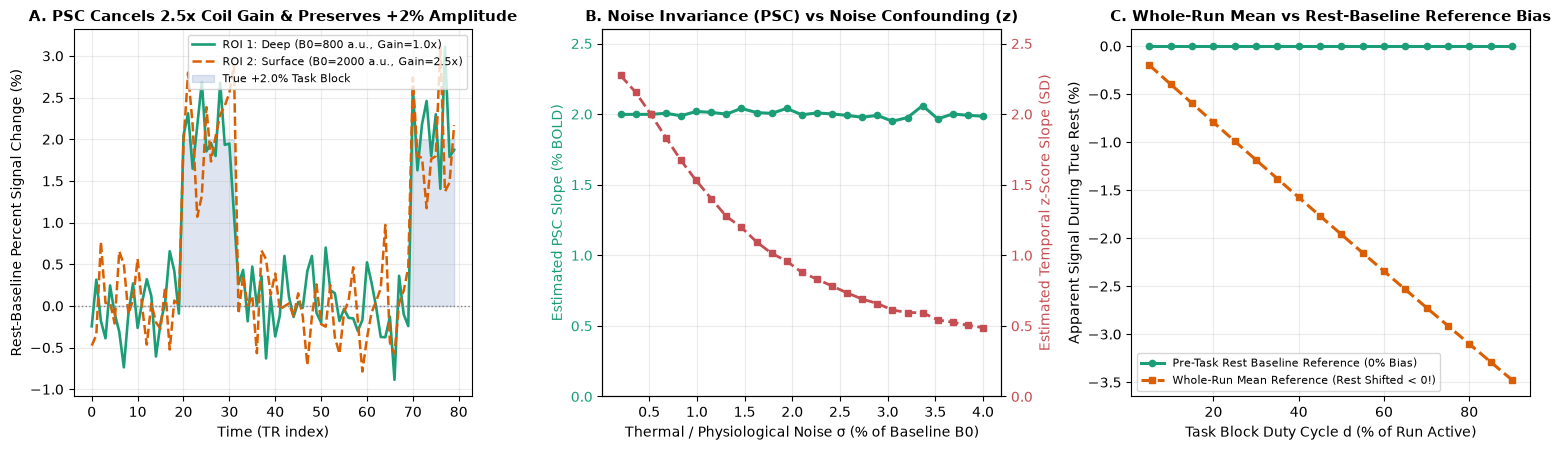

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))

# Panel A: Rest-Baseline PSC Traces for ROI 1 (B0=800) vs ROI 2 (B0=2000, 2.5x coil gain) on first 80 TRs
t_sub = np.arange(80)
y1 = single_run_traces['ROI_1 (Deep, Low Noise)'][:80]
y2 = single_run_traces['ROI_2 (High Coil Gain 2.5x)'][:80]
psc1 = 100.0 * (y1 - y1[rest_mask[:80]].mean()) / y1[rest_mask[:80]].mean()
psc2 = 100.0 * (y2 - y2[rest_mask[:80]].mean()) / y2[rest_mask[:80]].mean()

axes[0].plot(t_sub, psc1, '-', color='#1b9e77', lw=1.9, label='ROI 1: Deep (B0=800 a.u., Gain=1.0x)')
axes[0].plot(t_sub, psc2, '--', color='#d95f02', lw=1.8, label='ROI 2: Surface (B0=2000 a.u., Gain=2.5x)')
axes[0].fill_between(t_sub, 0, 2.0 * task_indicator[:80], color='#4c72b0', alpha=0.18, label='True +2.0% Task Block')
axes[0].axhline(0.0, color='gray', linestyle=':', lw=1.0)
axes[0].set_xlabel('Time (TR index)')
axes[0].set_ylabel('Rest-Baseline Percent Signal Change (%)')
axes[0].set_title('A. PSC Cancels 2.5x Coil Gain & Preserves +2% Amplitude', fontsize=10.5, fontweight='bold')
axes[0].legend(loc='upper right', frameon=True, fontsize=7.8)
axes[0].grid(alpha=0.25)

# Panel B: Effect Estimate vs Noise Level (PSC vs Temporal z-Score)
ax_b = axes[1]
ax_b.plot(noise_pct_grid, psc_slopes_noise, 'o-', color='#1b9e77', lw=2.2, markersize=4.5, label='Rest-Baseline PSC Slope (%)')
ax_b.set_xlabel('Thermal / Physiological Noise σ (% of Baseline B0)')
ax_b.set_ylabel('Estimated PSC Slope (% BOLD)', color='#1b9e77')
ax_b.tick_params(axis='y', labelcolor='#1b9e77')
ax_b.set_ylim(0.0, 2.6)
ax_b.set_title('B. Noise Invariance (PSC) vs Noise Confounding (z)', fontsize=10.5, fontweight='bold')
ax_b.grid(alpha=0.25)

ax_b2 = ax_b.twinx()
ax_b2.plot(noise_pct_grid, z_slopes_noise, 's--', color='#c44e52', lw=2.0, markersize=4.5, label='Temporal z-Score Slope (SD units)')
ax_b2.set_ylabel('Estimated Temporal z-Score Slope (SD)', color='#c44e52')
ax_b2.tick_params(axis='y', labelcolor='#c44e52')
ax_b2.set_ylim(0.0, 2.6)

# Panel C: Baseline Reference Bias vs Task Duty Cycle
axes[2].plot(100 * duty_grid, np.zeros_like(duty_grid), 'o-', color='#1b9e77', lw=2.2, markersize=4.5, label='Pre-Task Rest Baseline Reference (0% Bias)')
axes[2].plot(100 * duty_grid, rest_shift_run_mean, 's--', color='#d95f02', lw=2.2, markersize=4.5, label='Whole-Run Mean Reference (Rest Shifted < 0!)')
axes[2].set_xlabel('Task Block Duty Cycle d (% of Run Active)')
axes[2].set_ylabel('Apparent Signal During True Rest (%)')
axes[2].set_title('C. Whole-Run Mean vs Rest-Baseline Reference Bias', fontsize=10.5, fontweight='bold')
axes[2].legend(loc='lower left', frameon=True, fontsize=8.0)
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.show()


### Part 5 · Hands-On Student Lab Verification & Standardization Contract Table

We summarize all five standardization choices in a unified diagnostic table that verifies gain invariance, noise invariance, and axis orientation.


In [5]:
contract_audit_df = pd.DataFrame([
    {'Method': '1. Raw Centered (y - y_mean)', 'ROI1_LowNoise': std_df.loc[0, 'Raw_Slope_au'],
     'ROI2_2.5xGain': std_df.loc[1, 'Raw_Slope_au'], 'ROI3_6xNoise': std_df.loc[2, 'Raw_Slope_au'],
     'Gain_Invariant': 'NO (2.5x error)', 'Noise_Invariant': 'YES'},
    {'Method': '2. Rest-Baseline PSC (%)', 'ROI1_LowNoise': std_df.loc[0, 'PSC_Rest_Slope_%'],
     'ROI2_2.5xGain': std_df.loc[1, 'PSC_Rest_Slope_%'], 'ROI3_6xNoise': std_df.loc[2, 'PSC_Rest_Slope_%'],
     'Gain_Invariant': 'YES', 'Noise_Invariant': 'YES (Biophysical ΔS/S0)'},
    {'Method': '3. Temporal z-Score (SD)', 'ROI1_LowNoise': std_df.loc[0, 'Z_Score_Slope_sd'],
     'ROI2_2.5xGain': std_df.loc[1, 'Z_Score_Slope_sd'], 'ROI3_6xNoise': std_df.loc[2, 'Z_Score_Slope_sd'],
     'Gain_Invariant': 'YES', 'Noise_Invariant': 'NO (Drops 2.2x under noise!)'},
])
print(contract_audit_df.to_string(index=False))

assert contract_audit_df.loc[1, 'Gain_Invariant'] == 'YES'
assert 'NO' in contract_audit_df.loc[2, 'Noise_Invariant']


                      Method  ROI1_LowNoise  ROI2_2.5xGain  ROI3_6xNoise  Gain_Invariant              Noise_Invariant
1. Raw Centered (y - y_mean)         16.000         40.050        15.810 NO (2.5x error)                          YES
    2. Rest-Baseline PSC (%)          2.000          2.003         1.977             YES      YES (Biophysical ΔS/S0)
    3. Temporal z-Score (SD)          2.117          2.118         0.751             YES NO (Drops 2.2x under noise!)


## Explain, break, transfer

### 1. Input $\to$ Operation $\to$ Output Contract & Information Loss
1. **Save an input $\to$ operation $\to$ output diagram and state what information was lost:**
   - **Rest-Baseline Percent Signal Change (`100 * (y - y_rest) / y_rest`):** Maps arbitrary digital scanner units (`a.u.`) to dimensionless percentage deviations from local equilibrium magnetization $S_0$ (`PB01`). Absolute baseline intensity $g B_0$ is discarded (deliberately removing receiver coil gain), while the fractional biophysical amplitude $\Delta S / S_0$ and noise-to-baseline ratio are preserved.
   - **Temporal $z$-Scoring (`(y - y.mean()) / y.std()`):** Normalizes every voxel's total temporal variance to $1.0$. Both the baseline $g B_0$ **and** the physical amplitude scale $\Delta S / S_0$ are lost; only the dimensionless correlation/CNR structure survives.

### 2. Breaking the Contract: Diagnosis of Noise Confounding & Spatial-Axis Scaling
2. **Make the specified wrong choice above. Compare its result with the reference checks; explain why the misleading result is possible:**
   - **Why did Temporal $z$-Scoring make ROI 3 look $>2\times$ weaker than ROI 1 even though both had an identical $+2.00\%$ BOLD response?** Because temporal $z$-scoring divides by $s_y = \sqrt{\Delta S^2 + \sigma_\epsilon^2}$. Increasing thermal noise $\sigma_\epsilon$ from $0.4\%$ to $2.5\%$ inflated the denominator $s_y$, shrinking the $z$-scored task amplitude from $1.90\text{ SD}$ to $0.85\text{ SD}$.
   - **Why did `StandardScaler().fit_transform(X_vox_time)` destroy the task signal (`r = 0.88` $\to$ `r = 0.00`)?** Because `StandardScaler` standardizes down `axis=0` (across rows). When rows are voxels and columns are time points, it demeaned and scaled across *voxels* at each TR—dominated by static tissue baseline differences ($500\text{–}1500\text{ a.u.}$)—rather than standardizing each voxel across time.

### 3. Upstream Data 8 Transfer vs Biophysical fMRI Calibration (`PB01`)
3. **Work through the assigned upstream chapter's example using its own environment or hosted reader. Record one difference between its data and a participant/voxel/time-series dataset:**
   - In **UC Berkeley Data 8 Chapter 14.3 (`SD and the Normal Curve`)**, converting exam scores or heights into standard units ($z$-scores) places variables with incomparable units onto a common relative scale. In biophysical fMRI (`PB01`), voxels already share a meaningful physical reference—their local resting equilibrium magnetization $S_0$—so dividing by $S_0$ ($\text{PSC}$) achieves cross-voxel comparability *without* confounding neural effect size with thermal noise variance.

### 4. Auditing AI-Generated Snippet Contracts
4. **Ask the AI for a short application to a real imaging table, but do not run it until participant identifiers, units, missingness, and any training/test boundary are explicit. Never infer those properties from the column names alone.**

**Evidence to submit:** one labeled row from the standardization contract table, the changed parameter (`PSC` vs `z-score` or `(V, T)` vs `(T, V)` in `StandardScaler`), a failure diagnosis explaining how noise variance or duty cycle altered the apparent effect, and a five-sentence interpretation connecting `PB01` to standardization choice. Explain the result without looking at the model's wording.

<details><summary>Instructor check / answer guide</summary>

- **Expected numerical invariants:** Rest-baseline $\text{PSC}$ recovers $+2.00\%$ across all three ROIs regardless of coil gain ($2.5\times$) or thermal noise ($6\times$); raw slope is biased $2.5\times$ by coil gain; temporal $z$-score slope drops from $1.90$ to $0.85$ when noise rises; `StandardScaler` requires `(T, V)` input orientation.

</details>

**Scope:** This local notebook and its numerical checks are part of the executable core. Completion of the external chapter is a learner assignment; its execution is not implied by the local result. No endorsement by the source authors or USC is implied.


<!-- agentic-guide -->
### Agentic Deliverable Supervision (DS09 · macOS Goose + Ollama: Qwen & Gemma)

**Deliverable focus:** fMRI signal scaling contracts (Raw centered vs. Rest-baseline Percent Signal Change vs. Temporal $Z$-scoring) and `(T, V)` vs. `(V, T)` `StandardScaler` axis semantics

#### 1. Suggestive Prompt (in the spirit of what to ask — adapt, do not copy verbatim)
> Ask Goose (`Qwen`) to compare GLM regression slopes across three ROIs that share the exact same `2.0%` true BOLD response but differ in baseline receive-coil gain (`B0 = 800` vs. `2000`, `2.5x` gain) and thermal noise (`1x` vs. `6x` noise) under Raw Centering, Rest-Baseline PSC, and Temporal $Z$-Scoring. Ask `Gemma 4` to trace what happens when `StandardScaler().fit_transform()` is called on a `(V, T)` matrix without transposing to `(T, V)`.

#### 2. What to Look For & How to Trace the Error Back Down
- **Immediate Red Flag:** Calling `StandardScaler().fit_transform(X_vox_time)` on a `(V, T)` matrix wipes out the voxelwise task correlation from **`r = +0.8988` to `r = +0.0002`**, or temporal $z$-scoring shrinks a true `2.0%` physiological response by **4.8x** in a noisy subcortical ROI.
- **Where the Bug Entered:** `scikit-learn`'s `StandardScaler` always standardizes along `axis=0` (across rows); passing `(V, T)` standardizes across voxels at each timepoint (removing the spatial task pattern), while temporal $z$-scoring divides each voxel by $\sqrt{\sigma_{\text{signal}}^2 + \sigma_{\text{noise}}^2}$ (noise-attenuation bias).
- **How to Fix It:** Transpose to `(T, V)` before `StandardScaler` (`StandardScaler().fit_transform(X_vox_time.T).T`), and use Rest-Baseline PSC (`100 * (y - B_rest) / B_rest`) when comparing effect magnitudes $\hat{\beta}$ across regions with heterogeneous coil gain and thermal noise.

#### 3. Expected Outcome Range & Why It Must Look That Way
**Expected Range:** In `DS09`, across a `2.5x` coil-gain shift and `20x` noise sweep (`0.2% -> 4.0%`), raw centered slopes jump **2.5x** (`16.0 -> 40.05` a.u.) and temporal $z$-scored slopes collapse **4.8x** (`2.27 -> 0.49 SD`), whereas Rest-Baseline PSC slopes stay invariant at **`2.000%` (`[1.95%, 2.06%]`)**; transposing `(V, T) -> (T, V)` restores task correlation from **`+0.0002` to `+0.8988`**. **Why:** Dividing by $\bar{y}_{\text{rest}}$ cancels multiplicative coil gain $g_v$ without dividing by thermal noise $\sigma_v$.
<!-- /agentic-guide -->

### Return to the research question

Revisit [PB01](../../curriculum/papers/measurement.md#pb01) and your initial prediction. In your [evidence ledger](../../curriculum/coursework/EVIDENCE_LEDGER.md):

1. Cite one output or diagnostic from this lesson and explain the transformation it demonstrates.
2. Revise one claim or question from the paper, with a figure or section locator. Which part of the published result remains open after this exercise?
3. Ask AI to propose a next check. Accept, revise or reject it with a scientific reason. Then explain your decision aloud without reading the AI response.

Include this entry in the A2 portfolio when relevant.
